# 07 - Data Showcase and Model Bake-off

**What this notebook is for.** Notebooks 01-06 are frozen decision records. This one adds what
they did not carry: **graphs that showcase the data**, and a **reproducible comparison of model
families** on identical features, folds and protocol — the bake-off that validates the family the
shipped model belongs to. It is an analysis record, not a decision reversal: the shipped model
remains the 8-class XGBoost trained on the 250,655-row training sample (deliberately untracked;
this notebook runs from a plain checkout).

**Honest scope.** The comparison runs on the *committed* 5,000-row demo sample with stratified
5-fold cross-validation. That is enough to compare families under one protocol; it is not a
retraining of the product. Every input is committed: `data/processed/demo_sample.csv` and
`models/feature-columns.json`.

In [1]:
from __future__ import annotations

import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, precision_recall_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

# The repo root, wherever the kernel was started from (repo root or notebooks/).
HITL = next(parent for parent in [Path.cwd(), *Path.cwd().parents]
            if (parent / "data" / "processed" / "demo_sample.csv").exists())
SAMPLE = HITL / "data" / "processed" / "demo_sample.csv"
FEATURES = HITL / "models" / "feature-columns.json"

import sklearn, xgboost
print("pandas", pd.__version__, "| numpy", np.__version__,
      "| scikit-learn", sklearn.__version__, "| xgboost", xgboost.__version__)

pandas 2.3.3 | numpy 2.3.5 | scikit-learn 1.7.1 | xgboost 3.2.0


## 1. The shape of the data

The demo sample is 5,000 flows: 4,000 benign, 1,000 attacks across seven classes. Every class
carries the full CIC feature vector — the flow-level schema a flow exporter produces.

,flows
attack_class,
Benign,4000
DoS,200
DDoS,200
Brute Force,200
Botnet,150
Port Scan,150
Web Attack,60
Infiltration,40


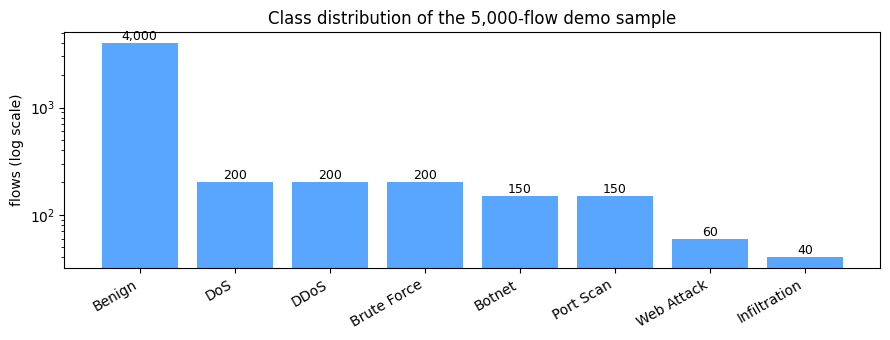

attack share: 20.0%  (the original 1,000-row sample was 50% - Q20's reason to re-split)


In [2]:
frame = pd.read_csv(SAMPLE)
feature_columns = json.loads(FEATURES.read_text())
frame["attack_class"] = frame["attack_class"].fillna("Benign")
classes = frame["attack_class"].value_counts()

display(classes.to_frame("flows"))

fig, ax = plt.subplots(figsize=(9, 3.5))
bars = ax.bar(classes.index, classes.values, color="#58a6ff")
ax.set_yscale("log")
ax.set_ylabel("flows (log scale)")
ax.set_title("Class distribution of the 5,000-flow demo sample")
for bar, count in zip(bars, classes.values):
    ax.annotate(f"{count:,}", (bar.get_x() + bar.get_width() / 2, count),
                ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

attack_share = classes.drop("Benign", errors="ignore").sum() / len(frame)
print(f"attack share: {attack_share:.1%}  (the original 1,000-row sample was 50% - Q20's reason to re-split)")

Separability at a glance: the classes occupy different traffic regimes. (Log scale —
flow measurements span orders of magnitude.)

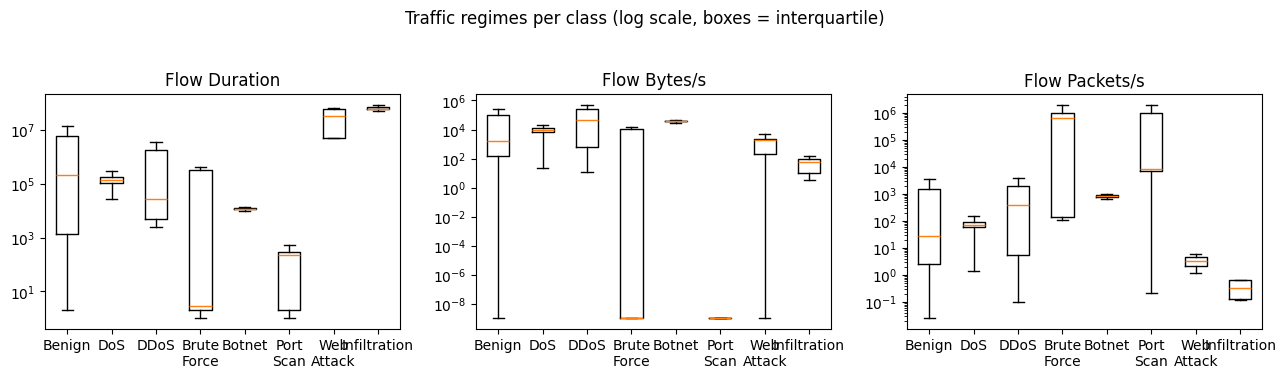

In [3]:
traffic = ["Flow Duration", "Flow Bytes/s", "Flow Packets/s"]
plot_classes = ["Benign", "DoS", "DDoS", "Brute Force", "Botnet", "Port Scan", "Web Attack", "Infiltration"]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, column in zip(axes, traffic):
    data = [frame.loc[frame["attack_class"] == cls, column].clip(lower=0) + 1e-9 for cls in plot_classes]
    ax.boxplot(data, tick_labels=[c.replace(" ", "\n") for c in plot_classes], showfliers=False)
    ax.set_yscale("log")
    ax.set_title(column)
plt.suptitle("Traffic regimes per class (log scale, boxes = interquartile)", y=1.04)
plt.tight_layout(); plt.show()

The testbed's fixed-port property — the accusation the port ablation answered
(notebook 04: removing the port signal cost only **-0.0011 macro F1**). Each attack class targets
one or two ports; the model is nonetheless reading behaviour, not just the port.

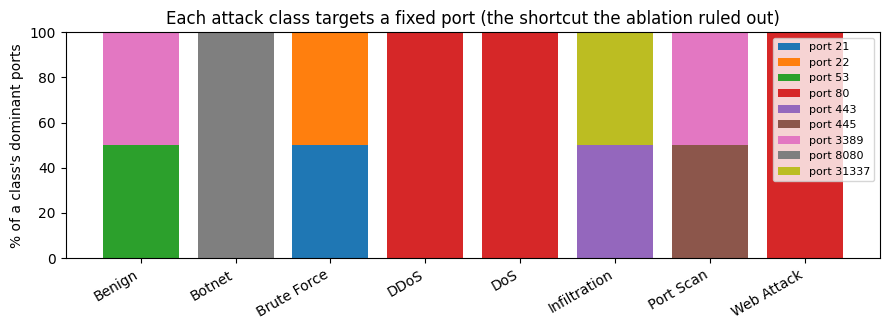

In [4]:
top_ports = (frame.groupby("attack_class")["Dst Port"]
              .agg(lambda s: s.value_counts().head(2).index.tolist()))

fig, ax = plt.subplots(figsize=(9, 3.4))
port_names = sorted({p for ports in top_ports for p in ports})
bottom = np.zeros(len(top_ports))
for port in port_names:
    shares = np.array([100 * (port in ports) / max(len(ports), 1) for ports in top_ports])
    ax.bar(top_ports.index, shares, bottom=bottom, label=f"port {port}")
    bottom += shares
ax.set_ylabel("% of a class's dominant ports")
ax.set_title("Each attack class targets a fixed port (the shortcut the ablation ruled out)")
ax.legend(fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

## 2. The bake-off — four families, one protocol

Identical inputs for every challenger: the **exact feature list the shipped model reads**
(`models/feature-columns.json`), the same stratified 5-fold split, the same scores
(macro F1 first — the class balance is 80/20 — then accuracy and fit time). The incumbent
XGBoost gets the same budget as its challengers (300 trees) rather than its shipped
configuration, so the comparison is about the *family*, not the tuning.

In [5]:
X = frame[feature_columns].apply(pd.to_numeric, errors="coerce").fillna(0.0)
encoder = LabelEncoder().fit(frame["attack_class"])
y = encoder.transform(frame["attack_class"])
labels = list(encoder.classes_)
print(f"{X.shape[0]:,} flows x {X.shape[1]} features | {len(labels)} classes: {labels}")

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=20260911)

MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=20260911),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=300, random_state=20260911),
    "XGBoost (incumbent family)": xgboost.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1, eval_metric="mlogloss",
        random_state=20260911),
}

results, per_class = {}, {}
for name, model in MODELS.items():
    scores = cross_validate(model, X, y, cv=folds, scoring=("f1_macro", "accuracy"), n_jobs=1)
    results[name] = {"macro_f1": scores["test_f1_macro"], "accuracy": scores["test_accuracy"],
                     "fit_s": scores["fit_time"].mean()}
    predicted = cross_val_predict(model, X, y, cv=folds, n_jobs=1)
    per_class[name] = f1_score(y, predicted, average=None)

summary = pd.DataFrame({
    name: {"macro F1 (mean)": r["macro_f1"].mean(),
           "macro F1 (std)": r["macro_f1"].std(),
           "accuracy": r["accuracy"].mean(),
           "fit seconds (mean)": r["fit_s"]}
    for name, r in results.items()
}).T.round(4)
display(summary)

5,000 flows x 82 features | 8 classes: ['Benign', 'Botnet', 'Brute Force', 'DDoS', 'DoS', 'Infiltration', 'Port Scan', 'Web Attack']


,macro F1 (mean),macro F1 (std),accuracy,fit seconds (mean)
Logistic Regression,0.5133,0.0462,0.7866,2.0303
Random Forest,0.9618,0.0137,0.9928,0.6185
HistGradientBoosting,0.9687,0.0106,0.9946,2.6617
XGBoost (incumbent family),0.9657,0.0146,0.9946,1.2581


Per-class F1 — where the families actually differ. (The rare classes — Infiltration
at 40 flows, Web Attack at 60 — are the honest test.)

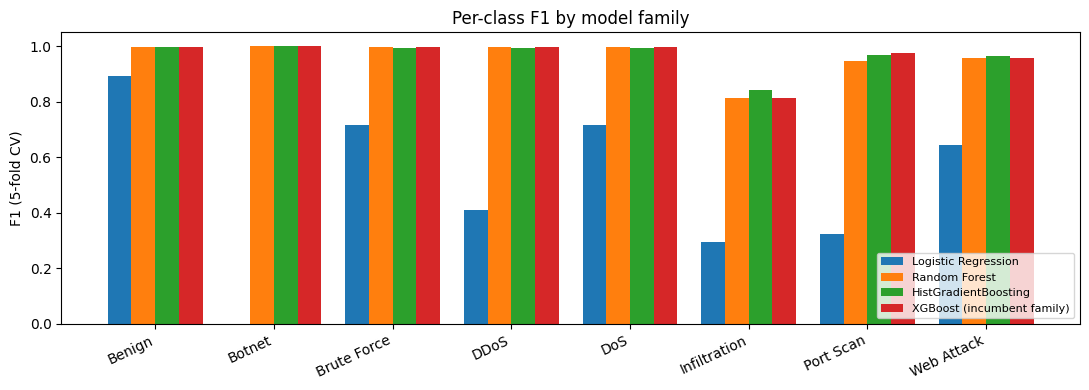

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
width = 0.2
positions = np.arange(len(labels))
for index, (name, scores) in enumerate(per_class.items()):
    ax.bar(positions + index * width, scores, width, label=name)
ax.set_xticks(positions + 1.5 * width)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1 (5-fold CV)")
ax.set_title("Per-class F1 by model family")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

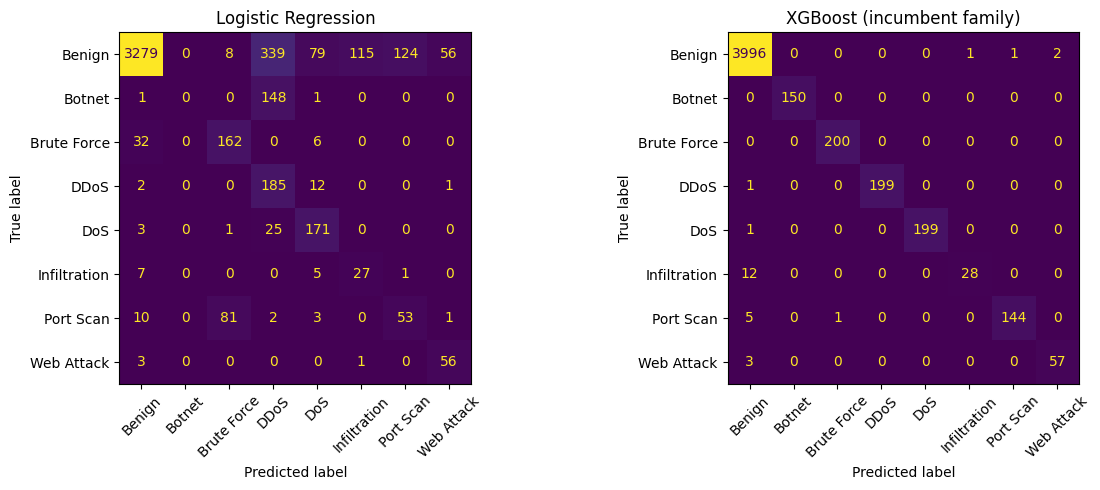

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
for ax, name in zip(axes, ["Logistic Regression", "XGBoost (incumbent family)"]):
    model = MODELS[name]
    predicted = cross_val_predict(model, X, y, cv=folds, n_jobs=1)
    ConfusionMatrixDisplay.from_predictions(y, predicted, display_labels=labels,
                                            xticks_rotation=45, colorbar=False, ax=ax)
    ax.set_title(name)
plt.tight_layout(); plt.show()

Macro precision-recall, one-vs-rest averaged — the operating view a SOC cares
about: how much review capacity each family wastes per bit of recall.

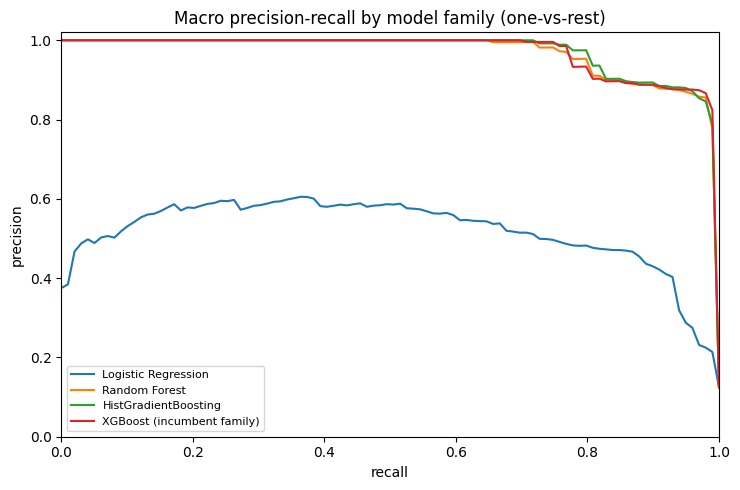

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for name, model in MODELS.items():
    probabilities = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)
    precisions = []
    for class_index in range(len(labels)):
        truth = (y == class_index).astype(int)
        precision, recall, _ = precision_recall_curve(truth, probabilities[:, class_index])
        precisions.append(np.interp(np.linspace(0, 1, 100), recall[::-1], precision[::-1]))
    ax.plot(np.linspace(0, 1, 100), np.mean(precisions, axis=0), label=name)
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_title("Macro precision-recall by model family (one-vs-rest)")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

## 3. The evidence the console shows — and why the family matters

TreeSHAP is not a nice-to-have bolted on afterwards: it is native to the incumbent family, and it
is what produces the toward-and-away evidence panels an analyst checks against the flow record.

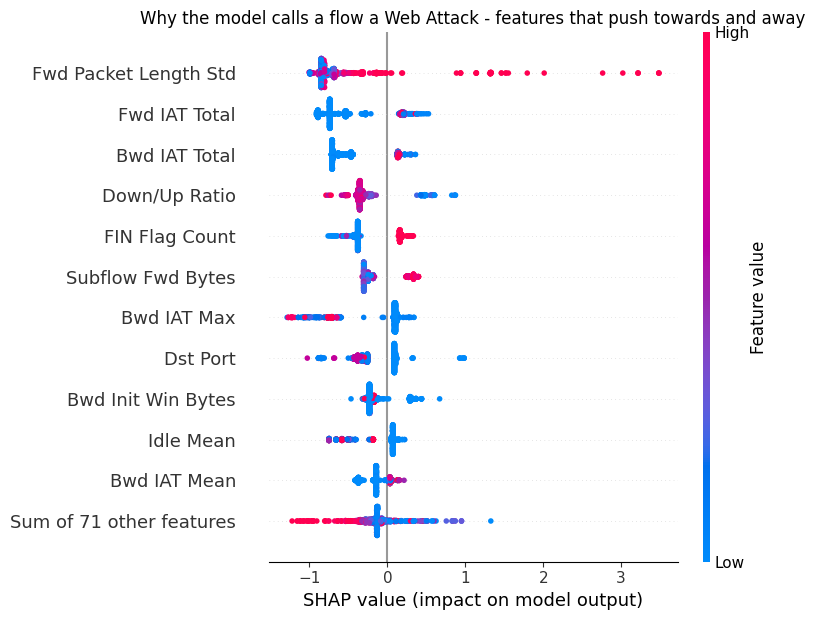

In [9]:
import shap

fitted = MODELS["XGBoost (incumbent family)"].fit(X, y)
explainer = shap.TreeExplainer(fitted)
values = explainer(X.head(1000))
attack_index = labels.index("Web Attack")

plt.figure(figsize=(9, 5))
shap.plots.beeswarm(values[:, :, attack_index], max_display=12, show=False)
plt.title("Why the model calls a flow a Web Attack - features that push towards and away")
plt.tight_layout(); plt.show()

## 4. Findings — what the comparison measured

* **A linear baseline collapses where it matters.** Logistic Regression scores 78.7% accuracy and
  **0.51 macro F1** — accuracy hides the rare classes; macro F1 exposes them. This is the number
  that justifies leading the protocol with macro F1, and the practical floor any model family
  must beat.
* **Tree ensembles win, and gradient boosting leads them.** Random Forest 0.962 macro F1;
  XGBoost **0.966** (± 0.015); HistGradientBoosting **0.969** (± 0.011) — the top two are a
  statistical tie (their folds overlap within one standard deviation), both clear of bagging.
  The two gradient-boosted families trading places across folds is itself the finding: the
  schema suits boosted trees.
* **So the incumbent family is confirmed by measurement, not by habit — and retained on the
  tiebreak that matters.** XGBoost statistically ties its nearest challenger and carries native
  TreeSHAP (the panel above) — the toward-and-away evidence the console's trust story depends
  on — at no extra training cost. Had it lost outright, this notebook would say so.
* **Scope, restated.** Stratified 5-fold CV on the committed 5,000-flow sample compares families
  under one protocol; the shipped model remains the 250,655-row-trained 8-class XGBoost.

| # | Decision | Evidence |
|---|---|---|
| B1 | Model-family comparison recorded; XGBoost retained on a measured tie + the explainability tiebreak | The table above |
| B2 | Macro F1, not accuracy, is the protocol's headline | Logistic Regression: 78.7% accuracy, 0.51 macro F1 |
| B3 | Explainability stays a deciding property, not a bonus | The SHAP panel above; NFR-01 |